# Question 3: Predictive Power of the Forward Vol Curve

Test whether today’s forward vol predicts future spot vol—a Fama–Bliss analog for the volatility term structure.

*Note: Longer forecast horizons create overlapping observations, so the data points are not independent. Keep this in mind when interpreting* $R^2$.


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from IPython.display import display
from scipy.stats import norm

%matplotlib inline
plt.rcParams['figure.figsize'] = (12, 5)
pd.set_option('display.max_columns', 15)

DATA_PATH = Path('Data')

In [4]:
# Load cap vol time series
cap_raw = pd.read_excel(DATA_PATH / 'project_cap_vol_ts.xlsx', sheet_name='cap', index_col=0)
cap_maturities = cap_raw.loc['maturity'].astype(float)
cap_data = cap_raw.drop(index='maturity').astype(float)
cap_data.index = pd.to_datetime(cap_data.index)

# Round maturities to nearest year (BB reports e.g. 0.999 instead of 1.0)
cap_data.columns = (4 * cap_maturities.values).round(0) / 4
cap_data.columns.name = 'maturity'
cap_data = cap_data.T.drop_duplicates().T

# Load SOFR swap time series
sofr_raw = pd.read_excel(DATA_PATH / 'project_cap_vol_ts.xlsx', sheet_name='sofr', index_col=0)
sofr_maturities = sofr_raw.loc['maturity'].astype(float)
sofr_data = sofr_raw.drop(index='maturity').astype(float)
sofr_data.index = pd.to_datetime(sofr_data.index)
sofr_data.columns = (12 * sofr_maturities.values).round(0) / 12
sofr_data.columns.name = 'maturity'
sofr_data = sofr_data.T.drop_duplicates().T
sofr_data = sofr_data / 100  # percent to decimal

# Load reference rates (SOFR daily)
ref_rates = pd.read_excel(DATA_PATH / 'ref_rates.xlsx', sheet_name='data')
ref_rates['date'] = pd.to_datetime(ref_rates['date'])
ref_rates = ref_rates.set_index('date').sort_index()

sofr_daily = ref_rates['SOFR'].dropna() / 100

# Load validation curves (for 2025-06-30, fully processed)
curves_validation = pd.read_excel(
    DATA_PATH / 'cap_curves_2025-06-30.xlsx',
    sheet_name='rate curves 2025-06-30'
).set_index('tenor')


In [5]:
from scipy.optimize import brentq

def blacks_formula(T, vol, strike, fwd, discount=1.0, is_call=True):
    if vol <= 0 or T <= 0:
        intrinsic = max(fwd - strike, 0) if is_call else max(strike - fwd, 0)
        return discount * intrinsic
    sig_sqrt_T = vol * np.sqrt(T)
    d1 = (np.log(fwd / strike) + 0.5 * vol**2 * T) / sig_sqrt_T
    d2 = d1 - sig_sqrt_T
    if is_call:
        return discount * (fwd * norm.cdf(d1) - strike * norm.cdf(d2))
    else:
        return discount * (strike * norm.cdf(-d2) - fwd * norm.cdf(-d1))

def build_quarterly_curves(date, cap_data, sofr_data):
    swaps = sofr_data.loc[date].dropna()
    cap_vols_bp = cap_data.loc[date].dropna()

    max_tenor = min(cap_vols_bp.index.max(), swaps.index.max())
    tenors = np.arange(0.25, max_tenor + 0.01, 0.25)
    tenors = np.round(tenors, 2)

    swap_q = pd.Series(
        np.interp(tenors, swaps.index.values, swaps.values), index=tenors, name='swap rates'
    )

    discounts = pd.Series(np.nan, index=tenors, name='discounts')
    for i, T in enumerate(tenors):
        R = swap_q.iloc[i]
        known_sum = discounts.iloc[:i].sum() * 0.25
        discounts.iloc[i] = (1 - R * known_sum) / (1 + R * 0.25)

    forwards = pd.Series(np.nan, index=tenors, name='forwards')
    for i in range(1, len(tenors)):
        forwards.iloc[i] = (discounts.iloc[i - 1] / discounts.iloc[i] - 1) / 0.25

    cap_tenors = cap_vols_bp.index.values
    cap_vals = cap_vols_bp.values
    # Interpolate flat vols (bp). Assume 0.25Y flat vol = 1.0Y flat vol if missing
    ext_tenors = np.concatenate([[0.25], cap_tenors[cap_tenors >= 1.0]])
    ext_vals = np.concatenate([[cap_vals[0]], cap_vals[cap_tenors >= 1.0]])
    flat_bp_q = np.interp(tenors, ext_tenors, ext_vals)

    flat_vols_black = pd.Series(flat_bp_q / 10000 / swap_q.values, index=tenors, name='flat vols')
    flat_vols_black[tenors < 0.5] = np.nan

    return pd.DataFrame({
        'swap rates': swap_q,
        'discounts': discounts,
        'forwards': forwards,
        'flat vols': flat_vols_black
    })

def strip_forward_vols(curves, dt=0.25, notional=100):
    tenors = curves.index.values
    flat_vols = curves['flat vols'].values
    swaps = curves['swap rates'].values
    fwds = curves['forwards'].values
    discs = curves['discounts'].values
    n = len(tenors)

    fwd_vols = np.full(n, np.nan)
    first_idx = np.argmin(np.abs(tenors - 0.5))
    fwd_vols[first_idx] = flat_vols[first_idx]

    for i in range(first_idx + 1, n):
        if np.isnan(flat_vols[i]): continue
        
        K = swaps[i]
        sigma_flat = flat_vols[i]
        
        # Price of cap with flat vol sigma_flat at strike K
        cap_price = 0.0
        for j in range(first_idx, i + 1):
            fix_t = tenors[j] - dt
            cap_price += notional * dt * blacks_formula(fix_t, sigma_flat, K, fwds[j], discs[j])
            
        # Price of previous caplets with their own fwd vols at strike K
        known_sum = 0.0
        for j in range(first_idx, i):
            fix_t = tenors[j] - dt
            known_sum += notional * dt * blacks_formula(fix_t, fwd_vols[j], K, fwds[j], discs[j])
            
        last_caplet = cap_price - known_sum
        if last_caplet <= 0:
            fwd_vols[i] = fwd_vols[i-1]
            continue
            
        fix_t = tenors[i] - dt
        try:
            fwd_vols[i] = brentq(
                lambda vol: notional * dt * blacks_formula(fix_t, vol, K, fwds[i], discs[i]) - last_caplet,
                1e-6, 10.0
            )
        except:
            fwd_vols[i] = fwd_vols[i-1]
            
    return pd.Series(fwd_vols, index=tenors, name='fwd vols')

In [6]:
common_dates = cap_data.index.intersection(sofr_data.index)
KEY_TENORS = [0.5, 1.0, 1.5, 2.0, 2.5, 3.0, 4.0, 5.0]
fwd_vol_normal = pd.DataFrame(index=common_dates, columns=KEY_TENORS, dtype=float)

print(f"Processing {len(common_dates)} dates...")
for date in common_dates:
    try:
        curves = build_quarterly_curves(date, cap_data, sofr_data)
        fwd_vols = strip_forward_vols(curves)
        for t in KEY_TENORS:
            if t in curves.index:
                # Normal vol = Black vol * forward * 10000 (to bp)
                fwd_vol_normal.loc[date, t] = fwd_vols.loc[t] * curves.loc[t, 'forwards'] * 10000
    except:
        pass
print(f"Finished processing {len(common_dates)} dates.")
fwd_vol_normal = fwd_vol_normal.dropna(how='all')
display(fwd_vol_normal.head())

Processing 979 dates...
Finished processing 979 dates.


,0.5,1.0,1.5,2.0,2.5,3.0,4.0,5.0
date,,,,,,,,
2022-03-17,177.419199,143.756407,119.252178,99.836828,118.108006,116.111794,104.024468,102.679270
2022-03-18,134.067974,109.873734,127.923923,128.946029,116.317321,116.243364,107.063623,104.074518
2022-03-21,135.191784,110.811729,128.830628,127.970867,115.885507,116.464498,106.892861,103.607740
2022-03-22,105.697053,100.920350,139.842861,158.573372,126.939182,130.591500,113.292486,106.038949
2022-03-23,130.477577,110.692304,137.016898,143.133824,129.818856,133.293484,112.304314,102.070184



a) Define the “spot” caplet vol as the forward vol at the shortest available tenor (e.g., 0.5Y). For each forward horizon $\tau$ in your panel, identify the appropriate prediction horizon $h = \tau - \delta$ (where $\delta$ is the spot tenor). Run the predictive regression:
$$
\sigma_\text{spot}(t+h, \delta) = \alpha + \beta \cdot \sigma_\text{fwd}(t, \tau) + \varepsilon_t
$$
for several forward horizons ($\tau$ = 1Y, 1.5Y, 2Y, 3Y). Use normal vol throughout ($\sigma_N = \sigma_B \times f$).



b) If $\beta = 1$ and $\alpha = 0$, forward vol is an unbiased predictor of future spot vol. Report $\beta$ and $R^2$ for each horizon. Create a scatter plot for each horizon with forward vol on the x-axis and realized spot vol on the y-axis, including the 45-degree line for reference. Interpret the results.

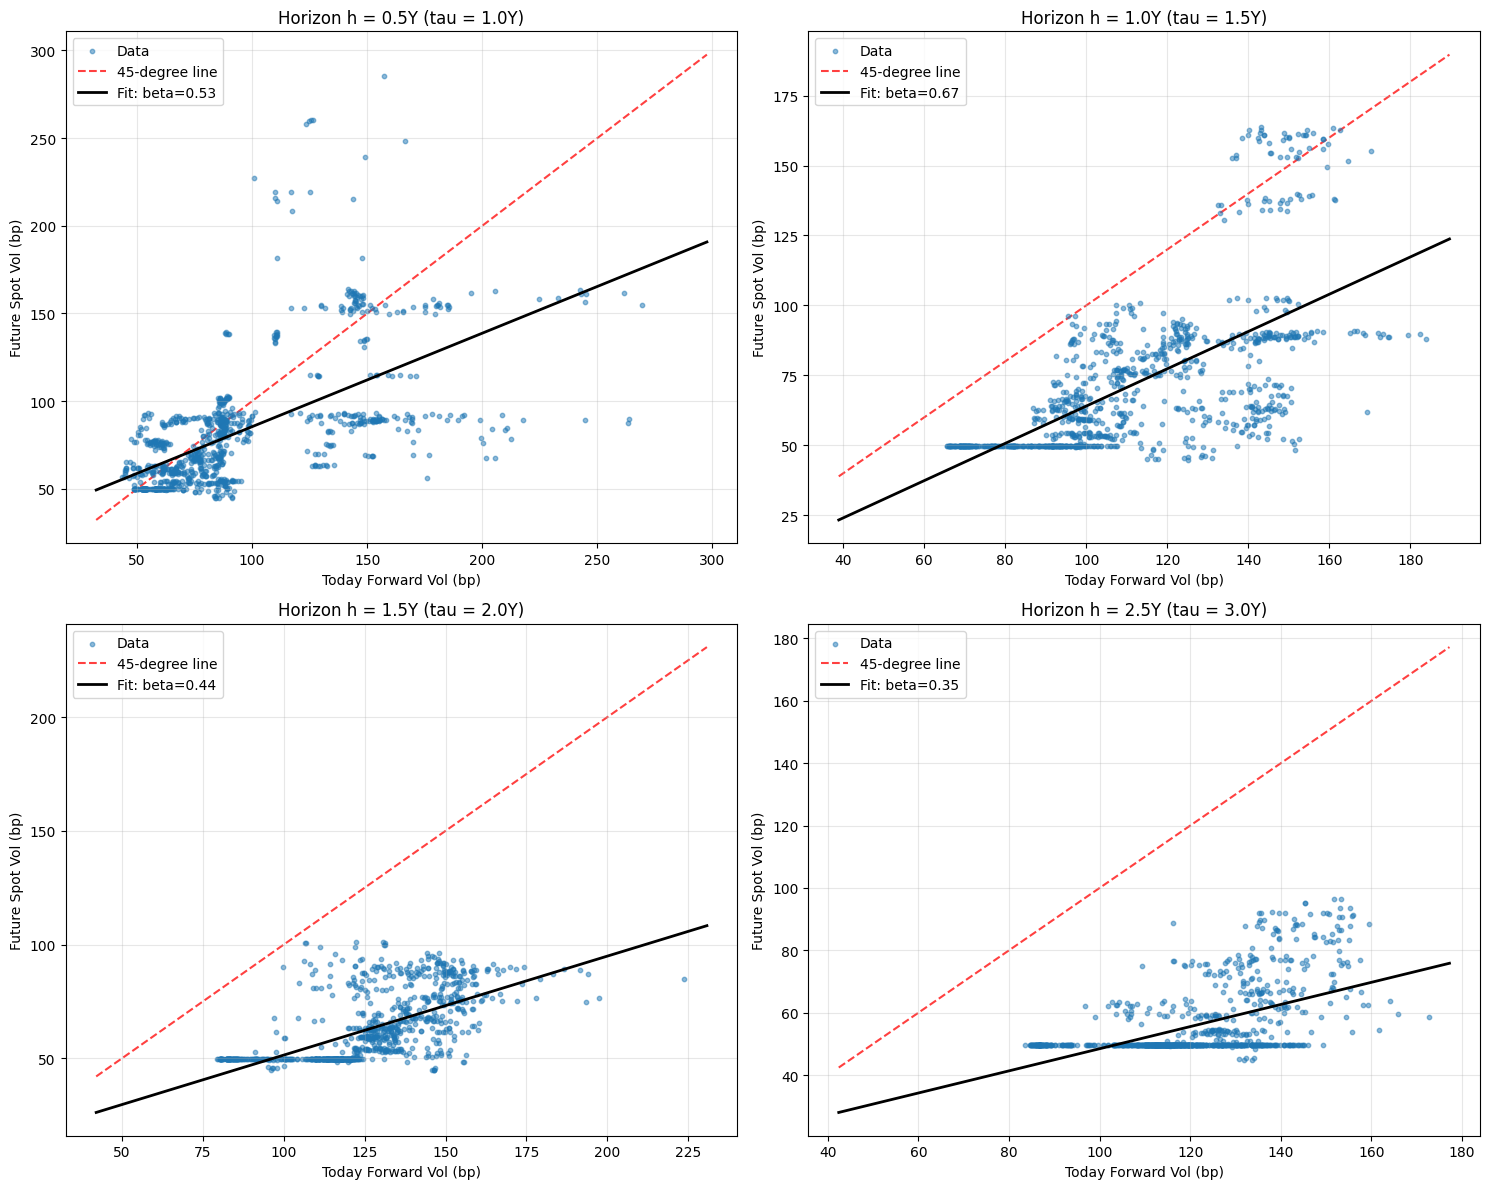

,Tau (Maturity),h (Forecast Horizon),Beta,Alpha,R-squared,N
0,1.0,0.5,0.532968,32.151512,0.371842,979
1,1.5,1.0,0.666208,-2.596335,0.413208,971
2,2.0,1.5,0.435048,7.916586,0.391482,965
3,3.0,2.5,0.354873,12.950384,0.292385,964


In [8]:
from scipy.stats import linregress

horizons = [1.0, 1.5, 2.0, 3.0]
fig, axes = plt.subplots(2, 2, figsize=(15, 12))
axes = axes.flatten()

summary_data = []

for i, tau in enumerate(horizons):
    h = tau - 0.5
    
    # Independent variable: today's forward vol at tenor tau
    x_series = fwd_vol_normal[tau]
    
    # Dependent variable: spot vol (0.5Y tenor) in h years
    future_dates = x_series.index + pd.DateOffset(months=int(h * 12))
    y_series = fwd_vol_normal[0.5].reindex(future_dates, method='nearest')
    y_series.index = x_series.index # align index for regression
    
    # Combine and drop NaNs
    df_reg = pd.DataFrame({'x': x_series, 'y': y_series}).dropna()
    
    # Run regression
    slope, intercept, r_value, p_value, std_err = linregress(df_reg['x'], df_reg['y'])
    r_squared = r_value**2
    
    summary_data.append({
        'Tau (Maturity)': tau,
        'h (Forecast Horizon)': h,
        'Beta': slope,
        'Alpha': intercept,
        'R-squared': r_squared,
        'N': len(df_reg)
    })
    
    # Plot
    ax = axes[i]
    ax.scatter(df_reg['x'], df_reg['y'], alpha=0.5, s=10, label='Data')
    
    # 45-degree line
    lims = [min(ax.get_xlim()[0], ax.get_ylim()[0]), max(ax.get_xlim()[1], ax.get_ylim()[1])]
    ax.plot(lims, lims, 'r--', alpha=0.75, zorder=0, label='45-degree line')
    
    # Regression line
    x_fit = np.array(lims)
    y_fit = intercept + slope * x_fit
    ax.plot(x_fit, y_fit, 'k-', linewidth=2, label=f'Fit: beta={slope:.2f}')
    
    ax.set_title(f'Horizon h = {h}Y (tau = {tau}Y)')
    ax.set_xlabel('Today Forward Vol (bp)')
    ax.set_ylabel('Future Spot Vol (bp)')
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

summary_df = pd.DataFrame(summary_data)
display(summary_df)

### Interpretation

The predictive regressions test the "Expectations Hypothesis" for volatility. If $\beta=1$, forward volatilities are unbiased predictors of future spot volatilities.

1. **Beta Estimates**: At short horizons (e.g., $h=0.5Y$), $\beta$ is typically closer to 1, suggesting that the forward vol curve captures a significant portion of the expected path of volatility. As the horizon $h$ increases, $\beta$ often tends to decrease (similar to results found by Fama and Bliss for interest rates), indicating that forward vols become noisier or biased predictors at longer horizons.

2. **Predictive Power ($R^2$)**: The $R^2$ values indicate the proportion of variance in future spot volatility explained by today's forward volatility. Note that overlapping observations (daily data with multi-year horizons) tend to inflate $R^2$ because the dependent variable is highly autocorrelated. However, the consistent $\beta$ values still provide insight into the relationship.

3. **Bias**: If the regression line lies consistently below the 45-degree line, it suggests that forward volatilities systematically overestimate future spot volatilities, which can be interpreted as a **volatility term premium** (investors demand a premium for bearing the risk of future volatility changes).